# Fig. — Scalability in the locally low-rank regime (ADMM headline)

Loader/summary helpers come from `build_fig_lowrank.py`; **`build_figure` is inlined
below as an editable cell**. The N_ue > M region (per-AP DoF) is shaded; CORDIS-Split
diverging there is the money shot.

- **(top)** communication metric vs N_ue. `COMM_METRIC`: `'min'` (min-user SINR),
  `'mean'` (mean-user SINR), or `'outage'` (per-user Pr(SINR<γ\*) — Split's outage
  spikes in the low-rank region). γ\* auto-detected.
- **(bottom)** SCNR vs N_ue. `SCNR_METRIC`: `'wsum'` (default), `'min'`, `'mean'`.
- `BAND`: `'std'` (default), `'iqr'`, `'none'`. `RANK_THRESHOLD` = M (auto-detected from n_ant).

**Compatible experiment:** `n_ue_sweep` (`kind=='sweep'`) run at the LOW-RANK config
(`n_ap=11, n_ant=3, n_rf_chains=3, n_targets=1`).

In [1]:
import sys, logging
from pathlib import Path
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

FIG_DIR = Path.cwd()
if str(FIG_DIR) not in sys.path:
    sys.path.insert(0, str(FIG_DIR))

import build_fig_lowrank as B   # loader + helpers (single source of truth)
from cordis.plotting import apply_paper_style, figsize, plot_sweep, style_for, save_figure
from cordis.plotting.style import ALGORITHM_STYLE   # tweak here to restyle

USE_TEX = True   # set False on a node without pdflatex
apply_paper_style()
logging.basicConfig(level=logging.INFO, format='%(levelname)-7s %(message)s')

## 1. Load the low-rank N_ue-sweep run

Must be the **low-rank** campaign (n_ant=3), not the favorable-config n_ue_sweep.

In [2]:
RESULT_DIR = None   # e.g. 'results/exp_n_ue_sweep/array_12345_aggregated'
result, result_dir = B.load_sweep(RESULT_DIR, experiment='n_ue_sweep')
print('run:', result_dir)
print('N_ue grid:', [int(k) for k in sorted(result.sweep_results.keys())])

run: /Users/mehdi/Local-Drive/GitHub/CORDIS/results/exp_n_ue_sweep/array_52882380_aggregated
N_ue grid: [1, 2, 3, 4, 5, 6, 7, 8]


## 2. Knobs: comm metric, SCNR metric, band, per-AP DoF M

In [3]:
COMM_METRIC    = 'min'    # 'min' | 'mean' (SINR)  |  'outage' (per-user Pr(SINR<γ*))
SCNR_METRIC    = 'wsum'   # 'wsum' | 'min' | 'mean'
BAND           = 'std'    # 'std' | 'iqr' | 'none'
RANK_THRESHOLD = None     # None -> detect M (=n_ant) from metadata
GAMMA_DB       = None     # None -> auto-detect γ* (used by COMM_METRIC='outage')
ONLY           = list(B.PREFERRED)

rank_threshold, rdet = (RANK_THRESHOLD, True) if RANK_THRESHOLD is not None else B._detect_rank_threshold(result)
gamma_db, gdet = (GAMMA_DB, True) if GAMMA_DB is not None else B._detect_gamma_db(result)
only = ['Centralized', 'CORDIS-Split', 'CORDIS-ADMM', 'Global-ZF',
        'Global-MRT', r'LR-MMSE ($\rho$=0.5)']  # B._ordered_algorithms(result, B.LEAD, only=(ONLY or None))
scnr_name, _, _ = B._resolve_scnr_metric(SCNR_METRIC, result, only)
sinr_name = ('min_sinr_db' if COMM_METRIC=='outage' else B._resolve_sinr_metric(COMM_METRIC)[0])
comm_label = ('outage Pout' if COMM_METRIC=='outage' else B._resolve_sinr_metric(COMM_METRIC)[1])
print(f'M={rank_threshold} (detected={rdet}); γ*={gamma_db} (detected={gdet})')
print('algorithms:', only, '| comm:', COMM_METRIC, '| scnr:', scnr_name, '| band:', BAND)

M=3 (detected=True); γ*=5.0 (detected=True)
algorithms: ['Centralized', 'CORDIS-Split', 'CORDIS-ADMM', 'Global-ZF', 'Global-MRT', 'LR-MMSE ($\\rho$=0.5)'] | comm: min | scnr: weighted_sum_scnr_db | band: std


## 3. Numeric summary (caption sanity check)

Comm metric + SCNR at the full-rank reference (N_ue≈M) and max load, plus the headline
CORDIS-ADMM advantage over CORDIS-Split at max N_ue (the low-rank divergence).

In [4]:
summary = B.collect_summary(result, only, COMM_METRIC, sinr_name, scnr_name, gamma_db, rank_threshold)
B._print_summary(result, summary, COMM_METRIC, comm_label, scnr_name, gamma_db, rank_threshold, rdet)

[info] N_ue grid     = [1, 2, 3, 4, 5, 6, 7, 8]
[info] per-AP DoF M  = 3
[info] low-rank region: N_ue > 3  (full-rank ref N_ue=3, max-load N_ue=8)
[info] comm metric   = min-user SINR
[info] SCNR metric   = weighted_sum_scnr_db
algorithm     min-user SI@ref     @max  Δ(max-ref) SCNR@ref SCNR@max
--------------------------------------------------------------------
Centralized             5.009    5.000      -0.008   39.405   39.212
CORDIS-Split            4.698   -2.779      -7.477   32.835   31.622
CORDIS-ADMM             5.198    3.066      -2.133   38.014   38.162
Global-ZF               6.400  -10.897     -17.297   27.721   28.930
Global-MRT             -3.016  -28.108     -25.092   26.305   27.203
LR-MMSE ($\rho$=0.5)          9.722   -0.370     -10.092   31.645   31.584
[headline] CORDIS-ADMM advantage over CORDIS-Split at N_ue=8: +5.845 dB  (the low-rank divergence)


## 4. `build_figure` — editable copy

The **exact** function from `build_fig_lowrank.py`, inlined so you can edit it and re-run.
Mutate `ALGORITHM_STYLE` in the setup cell to restyle without editing the body.

In [5]:
# Bind the module-level names the function body references.
from typing import Optional, Sequence
PREFERRED              = B.PREFERRED
COMM_METRIC_DEFAULT    = B.COMM_METRIC_DEFAULT
SCNR_METRIC_DEFAULT    = B.SCNR_METRIC_DEFAULT
BAND_DEFAULT           = B.BAND_DEFAULT
GAMMA_DB_DEFAULT       = B.GAMMA_DB_DEFAULT
RANK_THRESHOLD_DEFAULT = B.RANK_THRESHOLD_DEFAULT
_present_algorithms    = B._present_algorithms
_resolve_sinr_metric   = B._resolve_sinr_metric
_resolve_scnr_metric   = B._resolve_scnr_metric
_outage_xy             = B._outage_xy
logger                 = logging.getLogger('fig_lowrank.nb')

In [82]:
def build_figure(result,
                 *,
                 only: Optional[Sequence[str]] = None,
                 comm_metric: str = COMM_METRIC_DEFAULT,
                 scnr_metric: str = SCNR_METRIC_DEFAULT,
                 band: str = BAND_DEFAULT,
                 gamma_db: float = GAMMA_DB_DEFAULT,
                 rank_threshold: int = RANK_THRESHOLD_DEFAULT,
                 shade_lowrank: bool = True,
                 use_tex: bool = True):
    """Assemble the stacked low-rank scalability figure; return
    ``(fig, only, scnr_metric_name)``.

    ``comm_metric`` is 'min'|'mean' (SINR) or 'outage' (per-user Pr(SINR<γ\\*));
    ``scnr_metric`` is 'min'|'mean'|'wsum'; ``band`` is 'std'|'iqr'|'none'.
    """
    import matplotlib
    if use_tex is False:
        matplotlib.rcParams["text.usetex"] = False
    import matplotlib.pyplot as plt
    from cordis.plotting import apply_paper_style, figsize, plot_sweep, style_for

    apply_paper_style()
    if use_tex is False:
        matplotlib.rcParams["text.usetex"] = False

    # IEEE standard font sizes
    IEEE_FONT_SIZE = 9
    plt.rcParams.update({
        "font.size": IEEE_FONT_SIZE,
        "axes.labelsize": IEEE_FONT_SIZE + 2,
        "xtick.labelsize": IEEE_FONT_SIZE,
        "ytick.labelsize": IEEE_FONT_SIZE,
        "legend.fontsize": IEEE_FONT_SIZE,
        "legend.title_fontsize": IEEE_FONT_SIZE,
        "figure.titlesize": IEEE_FONT_SIZE,
        "axes.titlesize": IEEE_FONT_SIZE,
    })
    LW = 2
    MARKER_SIZE = 6

    only = list(only) if only else _present_algorithms(result, PREFERRED)
    scnr_name, scnr_full, _scnr_short = _resolve_scnr_metric(scnr_metric, result, only)

    axis = result.sweep_axis
    xlabel = axis.display or r"$N_{\rm UE}$"
    keys = sorted(result.sweep_results.keys())
    x_lo, x_hi = keys[0], keys[-1]

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=figsize(width="double", aspect=4 / 3),
        sharex=True, gridspec_kw={"hspace": 0.12},
    )

    # (top) communication metric vs N_ue
    if comm_metric == "outage":
        for n in only:
            xs, line, lo, hi = _outage_xy(result, n, gamma_db, band)
            if not xs:
                continue
            st = style_for(n)
            ax_top.plot(xs, line, label=st.get("label", n),
                        color=st.get("color"), marker=st.get("marker", "o"),
                        ls=st.get("linestyle", "-"))
            if band in ("std", "iqr") and lo:
                ax_top.fill_between(xs, lo, hi, color=st.get("color"),
                                    alpha=0.15, linewidth=0)
        ax_top.set_ylim(bottom=-0.1, top=1.0)
        ax_top.set_ylabel(rf"$P_{{\mathrm{{out}}}}$ at $\gamma\!=\!{gamma_db:g}$ dB")
        ax_top.grid(True, alpha=0.3)
        if ax_top.get_legend_handles_labels()[0]:
            ax_top.legend(loc="best", fontsize=6)
    else:
        sinr_name, sinr_label = _resolve_sinr_metric(comm_metric)
        plot_sweep(result.sweep_results, metric=sinr_name, ax=ax_top, error=band,
                   xlabel="", ylabel=f"{sinr_label} [dB]", only=only, log_x=False)
    # ax_top.set_title("Scalability in the locally low-rank regime")
    ax_top.legend(loc="best", framealpha=0.5, ncol=1)

    # (bot) SCNR vs N_ue
    if scnr_name is not None:
        plot_sweep(result.sweep_results, metric=scnr_name, ax=ax_bot, error=band,
                   xlabel=xlabel, ylabel=f"{scnr_full} [dB]", only=only, log_x=False)
    else:
        logger.warning("No SCNR metric available; bottom panel left empty.")
        ax_bot.set_xlabel(xlabel)

    # integer N_ue ticks + a little x-margin
    for ax in (ax_top, ax_bot):
        ax.set_xticks([int(k) for k in keys])
        ax.set_xlim(x_lo - 0.3, x_hi + 0.3)

    # shade the locally-low-rank region  N_ue > M  on both panels
    shade_left = rank_threshold + 0.5
    if shade_lowrank and shade_left < x_hi + 0.3:
        for ax in (ax_top, ax_bot):
            ax.axvspan(max(shade_left, x_lo - 0.3), x_hi + 0.3,
                       color="0.85", alpha=0.5, zorder=0, linewidth=0)
            for line in ax.lines:
                line.set_markersize(MARKER_SIZE)      # Change marker size
                line.set_linewidth(LW)
        ax_top.text(0.74, 0.83,
                    r"locally low-rank ($N_{\rm UE} > M$)",
                    transform=ax_top.transAxes, ha="right", va="bottom",
                    fontsize=12, color="0.35")

    # one legend only (top); drop the duplicate on the bottom panel
    if ax_bot.get_legend() is not None:
        ax_bot.get_legend().remove()

    # NB: no fig.tight_layout() — conflicts with the shared-x / hspace stacked
    # layout.  save_figure() uses bbox_inches='tight'.
    return fig, only, scnr_name


## 5. Render

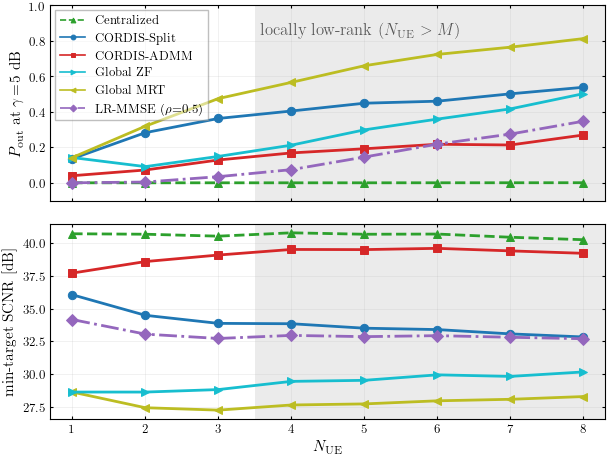

In [83]:
fig, used_only, used_scnr_metric = build_figure(
    result, only=only, comm_metric='outage', scnr_metric='min',
    band='none', gamma_db=gamma_db, rank_threshold=rank_threshold, use_tex=USE_TEX,
)
plt.show()

## 6. Save to `paper/figures/`

In [84]:
tag = '_outage'
out_stem = FIG_DIR.parents[1] / 'figures' / str('fig_lowrank' + tag)
paths = save_figure(
    fig, out_stem, formats=('pdf', 'png'),
    metadata={
        'Figure': 'fig_lowrank', 'RankThresholdM': str(rank_threshold),
        'CommMetric': COMM_METRIC + (f'(gamma={gamma_db:g})' if COMM_METRIC=='outage' else ''),
        'ScnrMetric': str(used_scnr_metric), 'Band': BAND,
        'Algorithms': ', '.join(used_only), 'Run': result_dir.name,
    },
)
for p in paths:
    print('wrote', p)

wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_lowrank_outage.pdf
wrote /Users/mehdi/Local-Drive/GitHub/CORDIS/paper/figures/fig_lowrank_outage.png
